### Run Flux.2 manually

To fully understand how sampling works in flow matching we are going to run generation loop manually.

In [1]:
from transformers import Qwen2TokenizerFast, Qwen3ForCausalLM, AutoConfig
import torch
import time
import torch
from diffusers.schedulers import FlowMatchEulerDiscreteScheduler
from diffusers.models import AutoencoderKLFlux2, Flux2Transformer2DModel
import numpy as np

import matplotlib.pyplot as plt
from diffusers.utils import load_image

device = "cuda"

In [2]:
dtype = torch.bfloat16

text_encoder = Qwen3ForCausalLM.from_pretrained("../../FLUX.2-klein-4B/text_encoder", local_files_only=True).to(device)
tokenizer = Qwen2TokenizerFast.from_pretrained("../../FLUX.2-klein-4B/tokenizer", local_files_only=True, device=device)

scheduler = FlowMatchEulerDiscreteScheduler.from_pretrained("../../FLUX.2-klein-4B/scheduler", device=device)
vae = AutoencoderKLFlux2.from_pretrained("../../FLUX.2-klein-4B/vae", device=device).to(device, dtype)
transformer = Flux2Transformer2DModel.from_pretrained("../../FLUX.2-klein-4B/transformer", device=device).to(device, dtype)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

### Step 1. Make text embeds

In [3]:
def _get_qwen3_prompt_embeds(
    text_encoder: Qwen3ForCausalLM,
    tokenizer: Qwen2TokenizerFast,
    prompt: str | list[str],
    dtype: torch.dtype | None = None,
    device: torch.device | None = None,
    max_sequence_length: int = 512,
    hidden_states_layers: list[int] = (9, 18, 27),
):
    dtype = text_encoder.dtype if dtype is None else dtype
    device = text_encoder.device if device is None else device

    prompt = [prompt] if isinstance(prompt, str) else prompt

    all_input_ids = []
    all_attention_masks = []

    for single_prompt in prompt:
        messages = [{"role": "user", "content": single_prompt}]
        text = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
            enable_thinking=False,
        )
        inputs = tokenizer(
            text,
            return_tensors="pt",
            padding="max_length",
            truncation=True,
            max_length=max_sequence_length,
        )

        all_input_ids.append(inputs["input_ids"])
        all_attention_masks.append(inputs["attention_mask"])

    input_ids = torch.cat(all_input_ids, dim=0).to(device)
    attention_mask = torch.cat(all_attention_masks, dim=0).to(device)

    # Forward pass through the model
    output = text_encoder(
        input_ids=input_ids,
        attention_mask=attention_mask,
        output_hidden_states=True,
        use_cache=False,
    )

    # Only use outputs from intermediate layers and stack them
    out = torch.stack(
        [output.hidden_states[k] for k in hidden_states_layers], dim=1
    )
    out = out.to(dtype=dtype, device=device)

    batch_size, num_channels, seq_len, hidden_dim = out.shape
    prompt_embeds = out.permute(0, 2, 1, 3).reshape(
        batch_size, seq_len, num_channels * hidden_dim
    )

    return prompt_embeds

def _prepare_text_ids(
    x: torch.Tensor,  # (B, L, D) or (L, D)
    t_coord: torch.Tensor | None = None,
):
    B, L, _ = x.shape
    out_ids = []

    for i in range(B):
        t = torch.arange(1) if t_coord is None else t_coord[i]
        h = torch.arange(1)
        w = torch.arange(1)
        l = torch.arange(L)

        coords = torch.cartesian_prod(t, h, w, l)
        out_ids.append(coords)

    return torch.stack(out_ids)

@torch.no_grad()
def encode_prompt(
    prompt: str | list[str],
    device: torch.device | None = None,
    num_images_per_prompt: int = 1,
    prompt_embeds: torch.Tensor | None = None,
    max_sequence_length: int = 512,
    text_encoder_out_layers: tuple[int] = (9, 18, 27),
):
    prompt = [prompt] if isinstance(prompt, str) else prompt

    prompt_embeds = _get_qwen3_prompt_embeds(
        text_encoder=text_encoder,
        tokenizer=tokenizer,
        prompt=prompt,
        device=device,
        max_sequence_length=max_sequence_length,
        hidden_states_layers=text_encoder_out_layers,
    )

    batch_size, seq_len, _ = prompt_embeds.shape
    prompt_embeds = prompt_embeds.repeat(1, num_images_per_prompt, 1)
    prompt_embeds = prompt_embeds.view(
        batch_size * num_images_per_prompt, seq_len, -1
    )

    text_ids = _prepare_text_ids(prompt_embeds)
    text_ids = text_ids.to(device)
    return prompt_embeds, text_ids

In [4]:
prompt = "A cat is on the green grass"

prompt_embeds, text_ids = encode_prompt(
    prompt=prompt,
    device=device,
    num_images_per_prompt=1,
    max_sequence_length=512,
    text_encoder_out_layers=(9, 18, 27),
)

In [5]:
print(prompt_embeds.shape)
print(text_ids.shape)
print(text_ids)

torch.Size([1, 512, 7680])
torch.Size([1, 512, 4])
tensor([[[  0,   0,   0,   0],
         [  0,   0,   0,   1],
         [  0,   0,   0,   2],
         ...,
         [  0,   0,   0, 509],
         [  0,   0,   0, 510],
         [  0,   0,   0, 511]]], device='cuda:0')


### Step 2. Make random latents

In [6]:
def _prepare_latent_ids(
    latents: torch.Tensor,  # (B, C, H, W)
):
    r"""
    Generates 4D position coordinates (T, H, W, L) for latent tensors.

    Args:
        latents (torch.Tensor):
            Latent tensor of shape (B, C, H, W)

    Returns:
        torch.Tensor:
            Position IDs tensor of shape (B, H*W, 4) All batches share the same coordinate structure: T=0,
            H=[0..H-1], W=[0..W-1], L=0
    """

    batch_size, _, height, width = latents.shape

    t = torch.arange(1)  # [0] - time dimension
    h = torch.arange(height)
    w = torch.arange(width)
    l = torch.arange(1)  # [0] - layer dimension

    # Create position IDs: (H*W, 4)
    latent_ids = torch.cartesian_prod(t, h, w, l)

    # Expand to batch: (B, H*W, 4)
    latent_ids = latent_ids.unsqueeze(0).expand(batch_size, -1, -1)

    return latent_ids


def _patchify_latents(latents):
    batch_size, num_channels_latents, height, width = latents.shape
    latents = latents.view(
        batch_size, num_channels_latents, height // 2, 2, width // 2, 2
    )
    latents = latents.permute(0, 1, 3, 5, 2, 4)
    latents = latents.reshape(
        batch_size, num_channels_latents * 4, height // 2, width // 2
    )
    return latents

def _unpatchify_latents(latents):
    batch_size, num_channels_latents, height, width = latents.shape
    latents = latents.reshape(
        batch_size, num_channels_latents // (2 * 2), 2, 2, height, width
    )
    latents = latents.permute(0, 1, 4, 2, 5, 3)
    latents = latents.reshape(
        batch_size, num_channels_latents // (2 * 2), height * 2, width * 2
    )
    return latents

def _pack_latents(latents):
    """
    pack latents: (batch_size, num_channels, height, width) -> (batch_size, height * width, num_channels)
    """

    batch_size, num_channels, height, width = latents.shape
    latents = latents.reshape(batch_size, num_channels, height * width).permute(
        0, 2, 1
    )

    return latents

def _unpack_latents_with_ids(
    x: torch.Tensor,
    x_ids: torch.Tensor,
    height: int | None = None,
    width: int | None = None,
) -> list[torch.Tensor]:
    """
    using position ids to scatter tokens into place
    """
    x_list = []
    for data, pos in zip(x, x_ids):
        _, ch = data.shape  # noqa: F841
        h_ids = pos[:, 1].to(torch.int64)
        w_ids = pos[:, 2].to(torch.int64)

        # Use provided height/width to avoid DtoH sync from torch.max().item()
        h = height if height is not None else torch.max(h_ids) + 1
        w = width if width is not None else torch.max(w_ids) + 1

        flat_ids = h_ids * w + w_ids

        out = torch.zeros((h * w, ch), device=data.device, dtype=data.dtype)
        out.scatter_(0, flat_ids.unsqueeze(1).expand(-1, ch), data)

        # reshape from (H * W, C) to (H, W, C) and permute to (C, H, W)

        out = out.view(h, w, ch).permute(2, 0, 1)
        x_list.append(out)

    return torch.stack(x_list, dim=0)

def prepare_latents(
    batch_size,
    num_latents_channels,
    height,
    width,
    dtype,
    device,
    generator: torch.Generator,
):
    # VAE applies 8x compression on images but we must also account for packing which requires
    # latent height and width to be divisible by 2.

    vae_scale_factor = 8
    height = 2 * (int(height) // (vae_scale_factor * 2))
    width = 2 * (int(width) // (vae_scale_factor * 2))

    shape = (batch_size, num_latents_channels * 4, height // 2, width // 2)

    latents = torch.randn(
        shape, generator=generator, device=device, dtype=dtype
    )

    latent_ids = _prepare_latent_ids(latents)
    latent_ids = latent_ids.to(device)

    latents = _pack_latents(latents)  # [B, C, H, W] -> [B, H*W, C]
    return latents, latent_ids

In [7]:
generator = torch.Generator(device="cuda").manual_seed(67)

height = 512
width = 512

latents, latent_ids = prepare_latents(
    batch_size=1,
    num_latents_channels=32,
    height=height,
    width=width,
    dtype=prompt_embeds.dtype,
    device=device,
    generator=generator,
)

In [8]:
print(latents.shape, latents.mean(), latents.std())
print(latent_ids.shape)
print(latent_ids)

torch.Size([1, 1024, 128]) tensor(0.0027, device='cuda:0', dtype=torch.bfloat16) tensor(1., device='cuda:0', dtype=torch.bfloat16)
torch.Size([1, 1024, 4])
tensor([[[ 0,  0,  0,  0],
         [ 0,  0,  1,  0],
         [ 0,  0,  2,  0],
         ...,
         [ 0, 31, 29,  0],
         [ 0, 31, 30,  0],
         [ 0, 31, 31,  0]]], device='cuda:0')


### Step 3. Timesteps and scheduler

In [ ]:
num_inference_steps = 50 # here can be 4

def retrieve_timesteps(
    scheduler,
    num_inference_steps: int,
    device: str | torch.device,
    sigmas: list[float],
    **kwargs,
):
    scheduler.set_timesteps(sigmas=sigmas, device=device, **kwargs)
    timesteps = scheduler.timesteps
    num_inference_steps = len(timesteps)

    return timesteps, num_inference_steps

def compute_empirical_mu(image_seq_len: int, num_steps: int) -> float:
    a1, b1 = 8.73809524e-05, 1.89833333
    a2, b2 = 0.00016927, 0.45666666

    if image_seq_len > 4300:
        mu = a2 * image_seq_len + b2
        return float(mu)

    m_200 = a2 * image_seq_len + b2
    m_10 = a1 * image_seq_len + b1

    a = (m_200 - m_10) / 190.0
    b = m_200 - 200.0 * a
    mu = a * num_steps + b

    return float(mu)

sigmas = np.linspace(1.0, 1 / num_inference_steps, num_inference_steps)

image_seq_len = latents.shape[1]

mu = compute_empirical_mu(
    image_seq_len=image_seq_len, num_steps=num_inference_steps
)

timesteps, num_inference_steps = retrieve_timesteps(
    scheduler,
    num_inference_steps,
    device,
    sigmas=sigmas,
    mu=mu,
)

In [10]:
print(timesteps)
print(num_inference_steps)
print(sigmas)
print(mu)

tensor([1000.0000,  996.2928,  992.4603,  988.4960,  984.3929,  980.1437,
         975.7405,  971.1745,  966.4368,  961.5173,  956.4055,  951.0898,
         945.5579,  939.7960,  933.7899,  927.5233,  920.9793,  914.1388,
         906.9812,  899.4840,  891.6224,  883.3691,  874.6943,  865.5646,
         855.9435,  845.7900,  835.0588,  823.6992,  811.6542,  798.8597,
         785.2439,  770.7247,  755.2095,  738.5917,  720.7499,  701.5435,
         680.8096,  658.3585,  633.9678,  607.3746,  578.2666,  546.2694,
         510.9303,  471.6968,  427.8878,  378.6533,  322.9187,  259.3059,
         186.0176,  100.6644], device='cuda:0')
50
[1.   0.98 0.96 0.94 0.92 0.9  0.88 0.86 0.84 0.82 0.8  0.78 0.76 0.74
 0.72 0.7  0.68 0.66 0.64 0.62 0.6  0.58 0.56 0.54 0.52 0.5  0.48 0.46
 0.44 0.42 0.4  0.38 0.36 0.34 0.32 0.3  0.28 0.26 0.24 0.22 0.2  0.18
 0.16 0.14 0.12 0.1  0.08 0.06 0.04 0.02]
1.7019562073086316


### Step 4. The actual denoising loop

Here I'm not only running the denoising loop as is, but also checks how the trajectory looks like by second denoising loop with same properties.

In [11]:
# The first run (actual normal denoising loop)

scheduler.set_begin_index(0)

init_latents = latents.clone()
for i, t in enumerate(timesteps):
    timestep = t.expand(latents.shape[0]).to(latents.dtype)

    latent_model_input = latents.to(transformer.dtype)
    latent_image_ids = latent_ids

    with torch.no_grad():
        noise_pred = transformer(
            hidden_states=latent_model_input,  # (B, image_seq_len, C)
            timestep=timestep / 1000,
            guidance=None,
            encoder_hidden_states=prompt_embeds,
            txt_ids=text_ids,  # B, text_seq_len, 4
            img_ids=latent_image_ids,  # B, image_seq_len, 4
            return_dict=False,
        )[0]

    noise_pred = noise_pred[:, : latents.size(1), :]

    # compute the previous noisy sample x_t -> x_t-1
    latents = scheduler.step(
        noise_pred, t, latents, return_dict=False
    )[0]

final_latents = latents.clone()

# The second run to measure trajectory curvature

timesteps, num_inference_steps = retrieve_timesteps(
    scheduler,
    num_inference_steps,
    device,
    sigmas=sigmas,
    mu=mu,
)
scheduler.set_begin_index(0)
latents = init_latents.clone()
for i, t in enumerate(timesteps):
    timestep = t.expand(latents.shape[0]).to(latents.dtype)

    latent_model_input = latents.to(transformer.dtype)
    latent_image_ids = latent_ids

    with torch.no_grad():
        noise_pred = transformer(
            hidden_states=latent_model_input,  # (B, image_seq_len, C)
            timestep=timestep / 1000,
            guidance=None,
            encoder_hidden_states=prompt_embeds,
            txt_ids=text_ids,  # B, text_seq_len, 4
            img_ids=latent_image_ids,  # B, image_seq_len, 4
            return_dict=False,
        )[0]

    noise_pred = noise_pred[:, : latents.size(1), :]

    # compute the previous noisy sample x_t -> x_t-1
    latents = scheduler.step(
        noise_pred, t, latents, return_dict=False
    )[0]

    sigma = timestep / 1000
    linear_path = init_latents * sigma + final_latents * (1 - sigma)
    a = torch.cos(torch.pi * sigma / 2)
    b = torch.sin(torch.pi * sigma / 2)
    gaussian_path = init_latents * b + final_latents * a
    linear_loss = (latents - linear_path) ** 2
    gaussian_loss = (latents - gaussian_path) ** 2
    print(sigma.mean().float().cpu().numpy(), linear_loss.mean().float().cpu().numpy(), gaussian_loss.mean().float().cpu().numpy())



1.0 1.8000603e-05 1.7762184e-05
0.99609375 4.6253204e-05 0.00017738342
0.9921875 0.00011444092 0.0005493164
0.98828125 0.00018501282 0.0006599426
0.984375 0.00029182434 0.0012741089
0.98046875 0.00040626526 0.002105713
0.9765625 0.0005531311 0.0031585693
0.97265625 0.000705719 0.0034179688
0.96875 0.00088882446 0.0047302246
0.9609375 0.0011444092 0.0067749023
0.95703125 0.0013580322 0.008605957
0.953125 0.0015945435 0.008972168
0.9453125 0.0019302368 0.012878418
0.94140625 0.0022277832 0.015380859
0.93359375 0.0026245117 0.018066406
0.9296875 0.0029449463 0.020507812
0.921875 0.00340271 0.026123047
0.9140625 0.0038909912 0.029785156
0.90625 0.004425049 0.03515625
0.8984375 0.0049743652 0.0390625
0.890625 0.005554199 0.045898438
0.8828125 0.006164551 0.052001953
0.875 0.0068359375 0.057128906
0.86328125 0.0076293945 0.064941406
0.85546875 0.008361816 0.07324219
0.84375 0.009216309 0.08154297
0.8359375 0.010070801 0.09277344
0.82421875 0.011108398 0.10058594
0.8125 0.012145996 0.11474609

So, the model is likely using a linear path objective, not a gaussian path.

In [12]:
print(latents.shape, latents.mean(), latents.std())

torch.Size([1, 1024, 128]) tensor(0.0310, device='cuda:0', dtype=torch.bfloat16) tensor(1.2266, device='cuda:0', dtype=torch.bfloat16)


### Step 5. decode latents

In [13]:
vae_scale_factor = 8

latent_height = 2 * (int(height) // (vae_scale_factor * 2))
latent_width = 2 * (int(width) // (vae_scale_factor * 2))
latents = _unpack_latents_with_ids(
    latents, latent_ids, latent_height // 2, latent_width // 2
)

latents_bn_mean = vae.bn.running_mean.view(1, -1, 1, 1).to(
    latents.device, latents.dtype
)
latents_bn_std = torch.sqrt(
    vae.bn.running_var.view(1, -1, 1, 1) + vae.config.batch_norm_eps
).to(latents.device, latents.dtype)

latents = latents * latents_bn_std + latents_bn_mean
latents = _unpatchify_latents(latents)

with torch.no_grad():
    image = vae.decode(latents.to(torch.bfloat16), return_dict=False)[0]

In [14]:
print(image.shape)

torch.Size([1, 3, 512, 512])


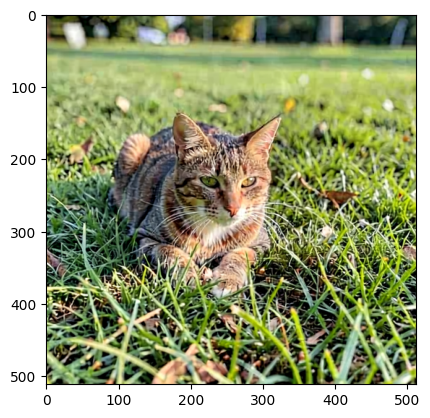

In [15]:
image = image.add(1).div(2)
image = image.float()
image = image.squeeze(0).permute(1, 2, 0)
image = image.clip(0, 1)
image = image.cpu().numpy()

plt.imshow(image)
plt.show()
